<h1 style="color:rgb(199, 12, 77);">Bitcoin Price Prediction using Machine Learning</h1>

<h2 style="color:rgb(247, 147, 26)">Notebook Objective</h2> 

The purpose of this notebook is to load and explore the Bitcoin historical market dataset, understand its structure, inspect data quality, and perform an initial overview analysis before preprocessing and model development.

 <h2 style="color:rgb(247, 147, 26)">Dataset Description</h2> 

This dataset contains historical Bitcoin market data recorded at 1-minute intervals. The dataset includes timestamp information along with Open, High, Low, Close, and Volume values representing Bitcoin trading activity over time.

The dataset will be used for exploratory data analysis, data cleaning, feature engineering, regression modeling, and Bitcoin price prediction.

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [8]:
df = pd.read_csv("../data/raw/btcusd_1-min_data.csv")

In [9]:
df.shape

(7536652, 6)

<h3 style="color:rgb(247, 147, 26)">Dataset Dimensions</h3> 

The dataset contains over 7.5 million rows and 6 columns.  
This indicates that the dataset represents a large-scale high-frequency Bitcoin market dataset recorded at 1-minute intervals.

In [12]:
df.head()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


<h3 style="color:rgb(247, 147, 26)">First Observations</h3> 

The first rows of the dataset show that Bitcoin prices were extremely low during the early years of the cryptocurrency market.  
The dataset contains OHLCV market data:
- Open
- High
- Low
- Close
- Volume

recorded at 1-minute intervals.

In [36]:
df.tail()

,Timestamp,Open,High,Low,Close,Volume,Date
7536647,1.777680e+09,78250.0,78250.0,78244.0,78245.0,0.233410,2026-05-02 00:08:00
7536648,1.777681e+09,78245.0,78254.0,78238.0,78254.0,0.792507,2026-05-02 00:09:00
7536649,1.777681e+09,78257.0,78257.0,78250.0,78256.0,0.101332,2026-05-02 00:10:00
7536650,1.777681e+09,78254.0,78254.0,78251.0,78251.0,0.208058,2026-05-02 00:11:00
7536651,1.777681e+09,78243.0,78244.0,78220.0,78220.0,0.207017,2026-05-02 00:12:00


<h3 style="color:rgb(247, 147, 26)">Latest Market Records</h3> 

The latest rows of the dataset show Bitcoin prices reaching significantly higher values compared to the early years of the dataset.  
This reflects the long-term growth and volatility of the Bitcoin market over time.

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7536652 entries, 0 to 7536651
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 345.0 MB


<h3 style="color:rgb(247, 147, 26)">Data Types and Structure</h3>

All columns are stored as float64 data types.  
The dataset does not contain categorical variables and is entirely numerical, making it highly suitable for regression and time-series analysis tasks.

The Timestamp column currently stores Unix timestamp values and will be converted into a readable datetime format.

In [29]:
df.describe()

,Timestamp,Open,High,Low,Close,Volume,Date
count,7.536652e+06,7.536652e+06,7.536652e+06,7.536652e+06,7.536652e+06,7.536652e+06,7536652
mean,1.551517e+09,2.291424e+04,2.292233e+04,2.290599e+04,2.291426e+04,5.037246e+00,2019-03-02 08:57:51.560132096
min,1.325412e+09,3.800000e+00,3.800000e+00,3.800000e+00,3.800000e+00,0.000000e+00,2012-01-01 10:01:00
25%,1.438462e+09,4.527100e+02,4.528600e+02,4.525100e+02,4.527075e+02,2.125472e-02,2015-08-01 20:43:45
50%,1.551512e+09,7.791000e+03,7.796850e+03,7.784990e+03,7.790675e+03,4.545712e-01,2019-03-02 07:26:30
75%,1.664561e+09,3.657900e+04,3.659800e+04,3.656126e+04,3.657900e+04,2.840000e+00,2022-09-30 18:09:15
max,1.777681e+09,1.262020e+05,1.262720e+05,1.261580e+05,1.262020e+05,5.853852e+03,2026-05-02 00:12:00
std,1.305474e+08,3.106083e+04,3.106924e+04,3.105236e+04,3.106085e+04,2.176645e+01,NaN


In [16]:
df.isnull().sum()

Timestamp    0
Open         0
High         0
Low          0
Close        0
Volume       0
dtype: int64

<h3 style="color:rgb(247, 147, 26)">Missing Value Analysis</h3>

No missing values were detected in the dataset.  
This is beneficial for machine learning workflows because additional imputation or missing-value preprocessing may not be required.

In [17]:
df["Date"] = pd.to_datetime(df["Timestamp"], unit="s")

<h3 style="color:rgb(247, 147, 26)">Datetime Conversion</h3>

The Timestamp column was successfully converted from Unix timestamp format into a human-readable datetime format.

This transformation improves:
- readability
- time-series analysis
- plotting
- feature engineering

and allows easier extraction of temporal features such as year, month, day, and hour.

In [37]:
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:01:00
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:02:00
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:03:00
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:04:00
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0,2012-01-01 10:05:00


In [38]:
df.tail()

,Timestamp,Open,High,Low,Close,Volume,Date
7536647,1.777680e+09,78250.0,78250.0,78244.0,78245.0,0.233410,2026-05-02 00:08:00
7536648,1.777681e+09,78245.0,78254.0,78238.0,78254.0,0.792507,2026-05-02 00:09:00
7536649,1.777681e+09,78257.0,78257.0,78250.0,78256.0,0.101332,2026-05-02 00:10:00
7536650,1.777681e+09,78254.0,78254.0,78251.0,78251.0,0.208058,2026-05-02 00:11:00
7536651,1.777681e+09,78243.0,78244.0,78220.0,78220.0,0.207017,2026-05-02 00:12:00


In [39]:
df.duplicated(subset=["Timestamp"]).sum()

np.int64(0)

<h3 style="color:rgb(247, 147, 26)">Timestamp Duplicate Analysis</h3>

No duplicated Timestamp values were detected in the dataset.

This indicates that each row represents a unique 1-minute market interval and confirms the integrity of the time-series structure.

In [28]:
df.duplicated(subset=["Open","High","Low","Close","Volume"]).sum()

np.int64(1196656)

<h3 style="color:rgb(247, 147, 26)">OHLCV Repetition Analysis</h3>

A considerable number of repeated OHLCV combinations were observed in the dataset.

However, this behavior is expected in high-frequency financial datasets because consecutive 1-minute intervals may occasionally exhibit identical market behavior during low-volatility periods.

Therefore, these repetitions are not considered true duplicate records.

In [42]:
df["Open"].max() # Bitcoin's all time highest price.

126202.0

In [41]:
df["Open"].min() # lowest opening price in the dataset

3.8

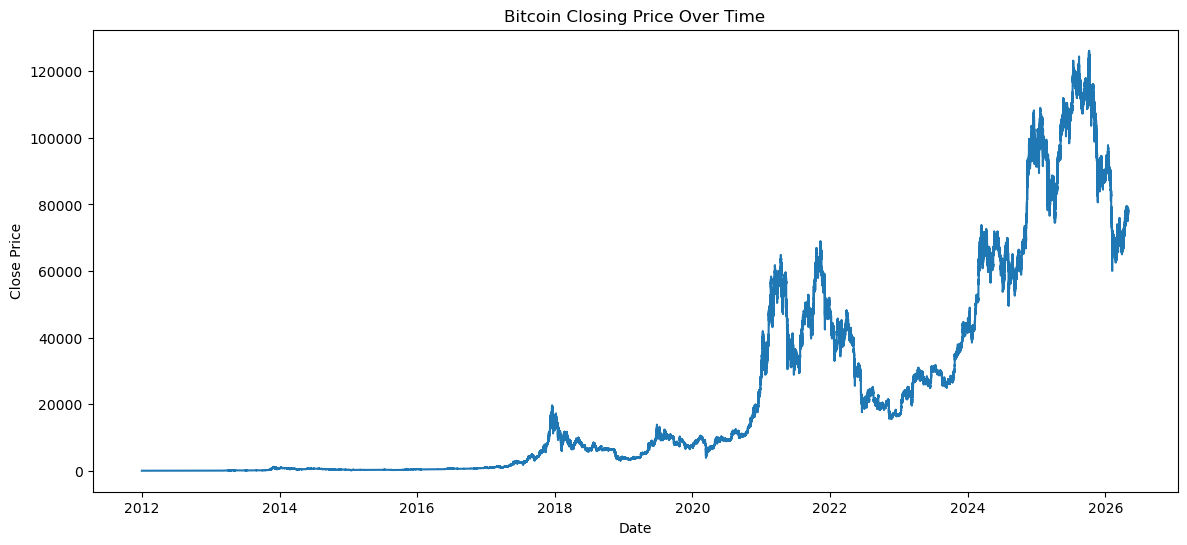

In [33]:
plt.figure(figsize=(14, 6))
plt.plot(df["Date"], df["Close"])
plt.title("Bitcoin Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Bitcoin Price Trend</h3>

> The time-series visualization clearly demonstrates the long-term upward trend and volatility of Bitcoin prices over the years.

> Large price fluctuations and rapid market growth can be observed throughout different market cycles.

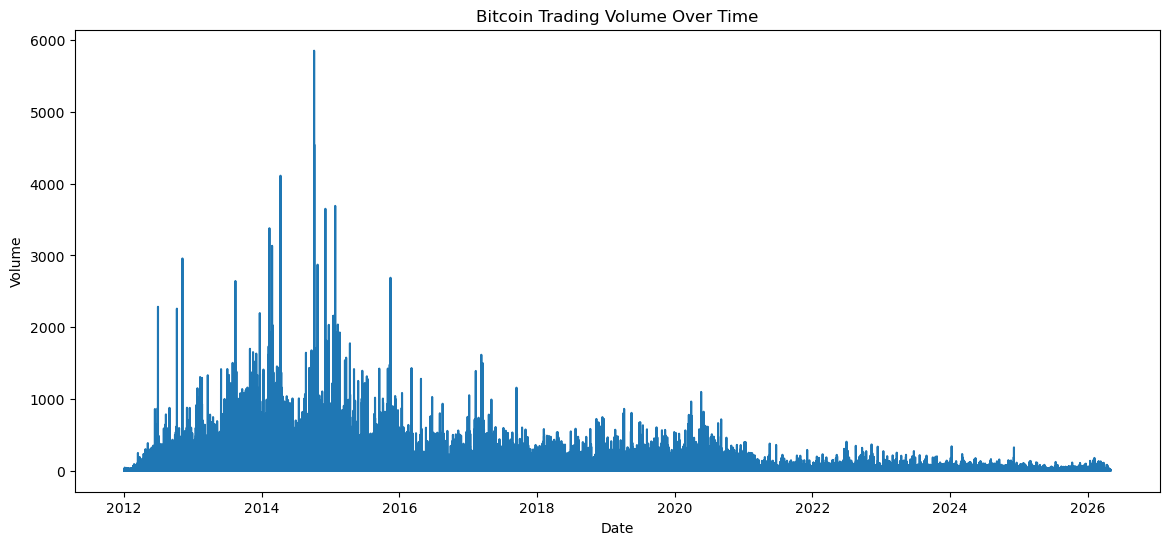

In [34]:
plt.figure(figsize=(14,6))
plt.plot(df["Date"],df["Volume"])
plt.title("Bitcoin Trading Volume Over Time")
plt.xlabel("Date")
plt.ylabel("Volume")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Trading Volume Analysis</h3>

> The Volume column represents the amount of Bitcoin traded during each 1-minute interval. 

> Periods of high trading volume may indicate increased market activity, stronger momentum, and higher investor participation.

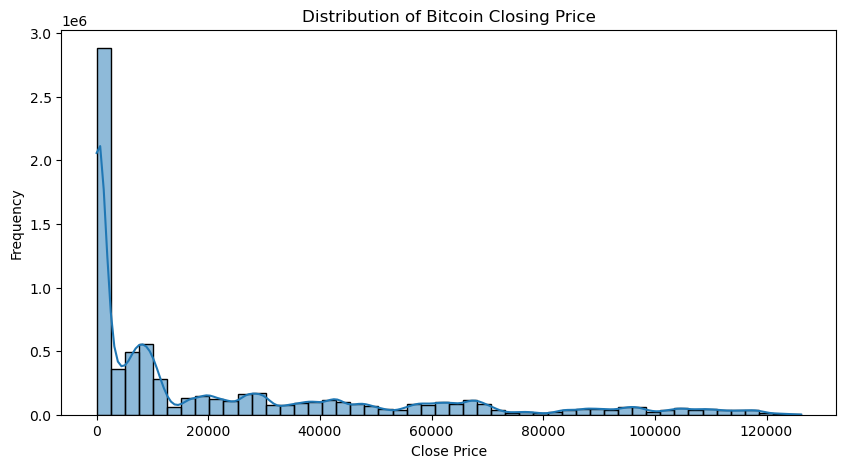

In [40]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Close"], bins=50, kde=True)
plt.title("Distribution of Bitcoin Closing Price")
plt.xlabel("Close Price")
plt.ylabel("Frequency")
plt.show()

> <h3 style="color:rgb(247, 147, 26)">Close Price Distribution></h3>

> The distribution of Bitcoin closing prices is heavily right-skewed due to the significant long-term increase in Bitcoin value over time.

> Lower Bitcoin prices dominate the early years of the dataset, while higher price ranges appear less frequently in later years.